In [1]:
import yt

ds = yt.load("AMRL2/plt22876")

fields = ds.field_list

for field in fields:
    print(field)

yt : [INFO     ] 2026-07-13 12:20:28,257 Parameters: current_time              = 0.0002
yt : [INFO     ] 2026-07-13 12:20:28,259 Parameters: domain_dimensions         = [400  48  16]
yt : [INFO     ] 2026-07-13 12:20:28,259 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-07-13 12:20:28,260 Parameters: domain_right_edge         = [12.5  1.5  0.5]


('boxlib', 'MachNumber')
('boxlib', 'Temp')
('boxlib', 'density')
('boxlib', 'magvel')
('boxlib', 'magvort')
('boxlib', 'pressure')
('boxlib', 'rho_AR')
('boxlib', 'rho_CO')
('boxlib', 'rho_CO2')
('boxlib', 'rho_E')
('boxlib', 'rho_H')
('boxlib', 'rho_H2')
('boxlib', 'rho_H2O')
('boxlib', 'rho_H2O2')
('boxlib', 'rho_HE')
('boxlib', 'rho_HO2')
('boxlib', 'rho_N2')
('boxlib', 'rho_O')
('boxlib', 'rho_O2')
('boxlib', 'rho_OH')
('boxlib', 'rho_e')
('boxlib', 'x_velocity')
('boxlib', 'xmom')
('boxlib', 'y_velocity')
('boxlib', 'ymom')
('boxlib', 'z_velocity')
('boxlib', 'zmom')


In [2]:
print("Dataset dimensionality:", ds.dimensionality)
print("Domain dimensions:", ds.domain_dimensions)
print("Domain left edge:", ds.domain_left_edge)
print("Domain right edge:", ds.domain_right_edge)

Dataset dimensionality: 3
Domain dimensions: [400  48  16]
Domain left edge: [0. 0. 0.] code_length
Domain right edge: [12.5  1.5  0.5] code_length


yt : [INFO     ] 2026-05-15 10:30:10,977 Parameters: current_time              = 0.0002
yt : [INFO     ] 2026-05-15 10:30:10,978 Parameters: domain_dimensions         = [400  48  16]
yt : [INFO     ] 2026-05-15 10:30:10,979 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-05-15 10:30:10,980 Parameters: domain_right_edge         = [12.5  1.5  0.5]
yt : [INFO     ] 2026-05-15 10:30:11,214 xlim = 0.000000 12.500000
yt : [INFO     ] 2026-05-15 10:30:11,216 ylim = 0.000000 1.500000
yt : [INFO     ] 2026-05-15 10:30:11,218 xlim = 0.000000 12.500000
yt : [INFO     ] 2026-05-15 10:30:11,219 ylim = 0.000000 1.500000
yt : [INFO     ] 2026-05-15 10:30:11,221 Making a fixed resolution buffer of (('gas', 'density')) 800 by 800



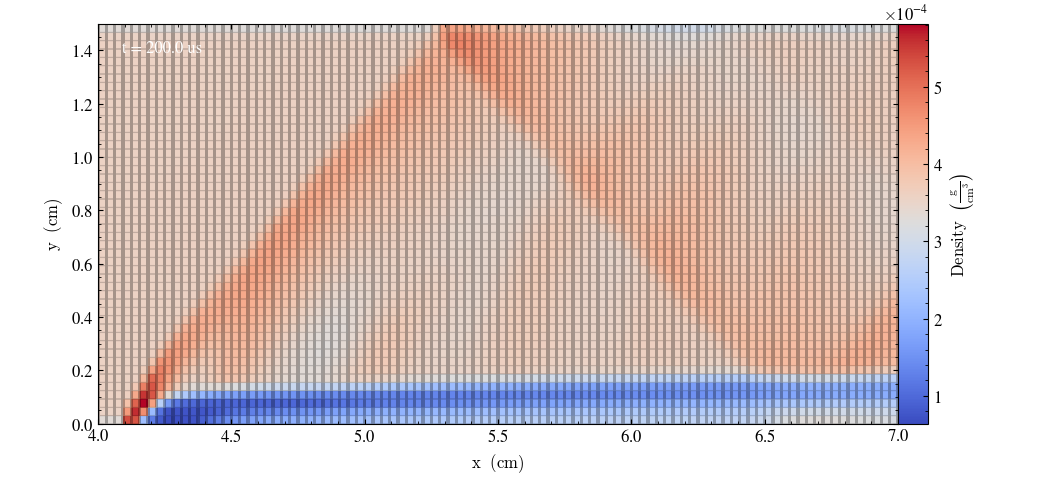

In [4]:
import yt
import numpy as np
import matplotlib.pyplot as plt

#ds = yt.load("plt186kdg01")
ds = yt.load("plt15604")

field = "density"
p = yt.SlicePlot(ds, "z", (field), origin = "native")

pan = (-0.75,0)
p.pan(pan)
p.set_width((3, 1.5))
p.set_font({"size":12})
p.set_log((field), False)

#p.set_buff_size((40000, 5000))

p.annotate_timestamp(corner="upper_left")

#p.annotate_grids(max_level=1, edgecolors=color, linewidth=0.5, alpha=0.7 )

p.annotate_cell_edges(alpha=0.3)

#colors = ["black", "dimgray", "darkgray", "gray"]
#for level, color in enumerate(colors):
#    p.annotate_grids(max_level=level, edgecolors=color, linewidth=0.5, alpha=0.9)
#    p.annotate_cell_edges(edgecolors=color,linewidth=0.5, alpha=0.7)
#    p.annotate_mesh_lines()
p.set_cmap((field), cmap="coolwarm")
#p.set_xlim((field), xmin=(4), xmax=(7))
#p.set_figure_size((12, 4))
#p.zoom(0.75)
#p.annotate_grids(linewidth=0.5, alpha=0.7)

p.show()

yt : [INFO     ] 2026-07-13 12:21:24,294 Parameters: current_time              = 0.0002
yt : [INFO     ] 2026-07-13 12:21:24,295 Parameters: domain_dimensions         = [400  48  16]
yt : [INFO     ] 2026-07-13 12:21:24,295 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-07-13 12:21:24,296 Parameters: domain_right_edge         = [12.5  1.5  0.5]
yt : [INFO     ] 2026-07-13 12:21:35,921 xlim = 0.000000 12.500000
yt : [INFO     ] 2026-07-13 12:21:35,922 ylim = 0.000000 1.500000
yt : [INFO     ] 2026-07-13 12:21:35,925 xlim = 0.000000 12.500000
yt : [INFO     ] 2026-07-13 12:21:35,926 ylim = 0.000000 1.500000
yt : [INFO     ] 2026-07-13 12:21:35,930 Making a fixed resolution buffer of (('gas', 'density_gradient_magnitude')) 800 by 800


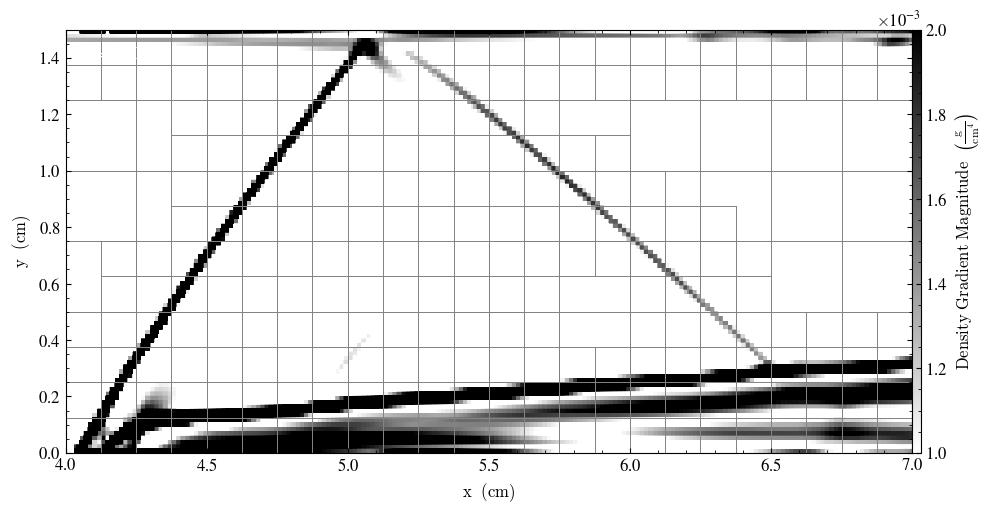

In [3]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import AxesGrid
import yt
import os


fns = [
    #"plt15604",
    #"plt16696",
    "AMRL2/plt22876",
    
]


def _laplacian(field, data):
    dp_dx = data[("density_gradient_x_gradient_x")]
    dp_dy = data[("density_gradient_y_gradient_y")]
    dp_dz = data[("density_gradient_z_gradient_z")]
    density_laplacian = dp_dx + dp_dy+ dp_dz
    return density_laplacian


fig = plt.figure(figsize=(6*8.4, 3*8.4))
grid = AxesGrid(
    fig,
    (0.06, 0.1, 0.85, 0.85),
    nrows_ncols=(1, 1),
    axes_pad=0.00,
    label_mode="1",
    share_all=True,
    cbar_location="right",
    cbar_mode="single",
    cbar_size="1%",
    cbar_pad="0%",
)

field = "density_gradient_magnitude"

for i, fn in enumerate(fns):
    ds = yt.load(fn)

    
    ds.add_gradient_fields(("density"))
    ds.add_gradient_fields(("density_gradient_x"))
    ds.add_gradient_fields(("density_gradient_y"))
    ds.add_gradient_fields(("density_gradient_z"))

   
    ds.add_field(("boxlib", "laplacian"), function=_laplacian,
                 display_name="Schlieren",
                 sampling_type="cell")

    ds.force_periodicity()

    slc = yt.SlicePlot(ds, "z", field, origin = "native")
    pan = (-0.75,0)
    slc.set_width((3, 1.5))
    slc.pan(pan)
    slc.set_font({"size":12})
    slc.set_log((field), False)

    
    slc.annotate_timestamp(corner="upper_left")

    colors = ["black", "dimgray", "darkgray", "gray"]
    for level, color in enumerate(colors):
        slc.annotate_grids(max_level=level, edgecolors=color, linewidth=0.5, alpha=0.9)
        
        #slc.annotate_grids()
    
    
    #slc.set_cmap((field), cmap="coolwarm")
    slc.set_cmap(field, cmap="binary")
    slc.set_zlim((field), zmin=(1e-3), zmax=(2e-3))

    # Assign to Matplotlib figure grid
    plot = slc.plots[field]
    plot.figure = fig
    plot.axes = grid[i].axes
    plot.cax = grid.cbar_axes[i]

    # Render the plot
    slc.render()


#plt.savefig("numericalschlieren.png")
plt.show()


yt : [INFO     ] 2026-05-20 18:28:30,259 Parameters: current_time              = 0.0002
yt : [INFO     ] 2026-05-20 18:28:30,261 Parameters: domain_dimensions         = [400  48  16]
yt : [INFO     ] 2026-05-20 18:28:30,263 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-05-20 18:28:30,264 Parameters: domain_right_edge         = [12.5  1.5  0.5]
yt : [INFO     ] 2026-05-20 18:28:34,067 xlim = 0.000000 12.500000
yt : [INFO     ] 2026-05-20 18:28:34,069 ylim = 0.000000 1.500000
yt : [INFO     ] 2026-05-20 18:28:34,072 xlim = 0.000000 12.500000
yt : [INFO     ] 2026-05-20 18:28:34,073 ylim = 0.000000 1.500000
yt : [INFO     ] 2026-05-20 18:28:34,077 Making a fixed resolution buffer of (('gas', 'density_gradient_magnitude')) 800 by 800


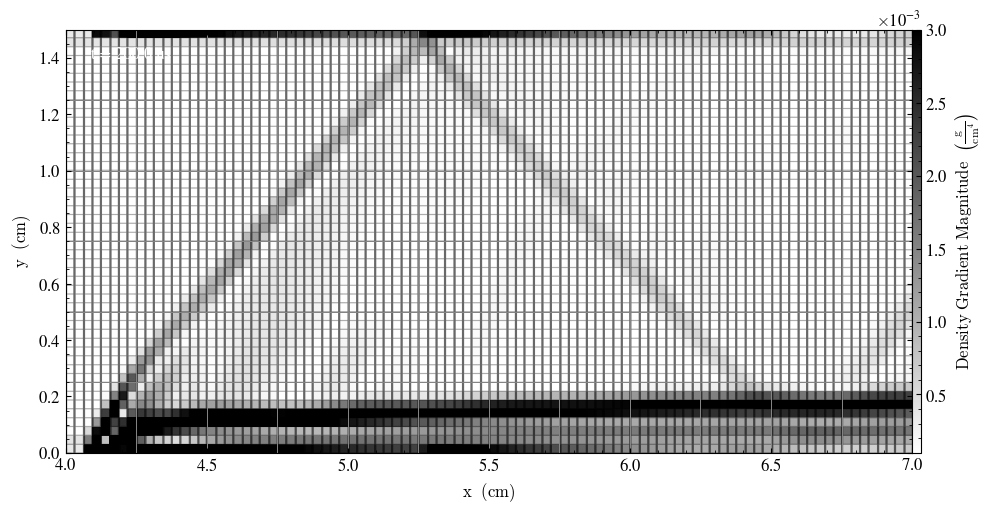

In [6]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import AxesGrid
import yt
import os


fns = [
    "plt15604",
    #"plt16696",
    #"plt23116",
    #"plt115593",
    #"plt186kdg01",
    
]


def _laplacian(field, data):
    dp_dx = data[("density_gradient_x_gradient_x")]
    dp_dy = data[("density_gradient_y_gradient_y")]
    dp_dz = data[("density_gradient_z_gradient_z")]
    density_laplacian = dp_dx + dp_dy+ dp_dz
    return density_laplacian


fig = plt.figure(figsize=(6*8.4, 3*8.4))
grid = AxesGrid(
    fig,
    (0.06, 0.1, 0.85, 0.85),
    nrows_ncols=(1, 1),
    axes_pad=0.00,
    label_mode="1",
    share_all=True,
    cbar_location="right",
    cbar_mode="single",
    cbar_size="1%",
    cbar_pad="0%",
)

field = "density_gradient_magnitude"

for i, fn in enumerate(fns):
    ds = yt.load(fn)

    
    ds.add_gradient_fields(("density"))
    ds.add_gradient_fields(("density_gradient_x"))
    ds.add_gradient_fields(("density_gradient_y"))
    ds.add_gradient_fields(("density_gradient_z"))

   
    ds.add_field(("boxlib", "laplacian"), function=_laplacian,
                 display_name="Schlieren",
                 sampling_type="cell")

    ds.force_periodicity()

    slc = yt.SlicePlot(ds, "z", field, origin = "native")
    pan = (-0.75,0)
    slc.set_width((3, 1.5))
    slc.pan(pan)
    slc.set_font({"size":12})
    slc.set_log((field), False)

    
    slc.annotate_timestamp(corner="upper_left")

    colors = ["black", "dimgray", "darkgray", "gray"]
    for level, color in enumerate(colors):
        slc.annotate_grids(max_level=level, edgecolors=color, linewidth=0.5, alpha=0.9)
        slc.annotate_cell_edges(line_width=0.00001, alpha=0.2)   
    #slc.annotate_grids()
    
    #slc.annotate_cell_edges(linewidth=0.5, alpha=0.7)
    #slc.set_cmap((field), cmap="coolwarm")
    slc.set_cmap(field, cmap="binary")
    slc.set_zlim((field), zmin=(0.1e-3), zmax=(3e-3))

    # Assign to Matplotlib figure grid
    plot = slc.plots[field]
    plot.figure = fig
    plot.axes = grid[i].axes
    plot.cax = grid.cbar_axes[i]

    # Render the plot
    slc.render()


#plt.savefig("numericalschlieren.png", dpi=400)
plt.show()


yt : [INFO     ] 2026-07-13 12:36:53,527 Parameters: current_time              = 0.0002
yt : [INFO     ] 2026-07-13 12:36:53,528 Parameters: domain_dimensions         = [400  48  16]
yt : [INFO     ] 2026-07-13 12:36:53,529 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-07-13 12:36:53,530 Parameters: domain_right_edge         = [12.5  1.5  0.5]
yt : [INFO     ] 2026-07-13 12:37:08,429 xlim = 0.000000 12.500000
yt : [INFO     ] 2026-07-13 12:37:08,430 ylim = 0.000000 1.500000
yt : [INFO     ] 2026-07-13 12:37:08,433 xlim = 0.000000 12.500000
yt : [INFO     ] 2026-07-13 12:37:08,434 ylim = 0.000000 1.500000
yt : [INFO     ] 2026-07-13 12:37:08,435 Making a fixed resolution buffer of (('gas', 'density_gradient_magnitude')) 800 by 800


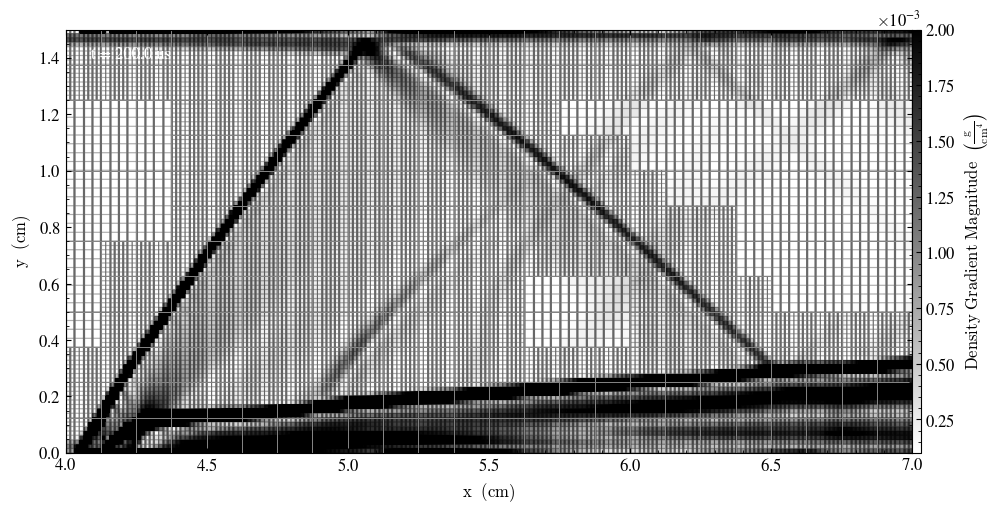

In [22]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import AxesGrid
import yt
import os


fns = [
    #"plt125000",
    #"plt15604",
    #"plt16696",
    #"plt23116",
    "AMRL2/plt22876"
    
]


def _laplacian(field, data):
    dp_dx = data[("density_gradient_x_gradient_x")]
    dp_dy = data[("density_gradient_y_gradient_y")]
    dp_dz = data[("density_gradient_z_gradient_z")]
    density_laplacian = dp_dx + dp_dy+ dp_dz
    return density_laplacian


fig = plt.figure(figsize=(6*8.4, 3*8.4))
grid = AxesGrid(
    fig,
    (0.06, 0.1, 0.85, 0.85),
    nrows_ncols=(1, 1),
    axes_pad=0.00,
    label_mode="1",
    share_all=True,
    cbar_location="right",
    cbar_mode="single",
    cbar_size="1%",
    cbar_pad="0%",
)

field = "density_gradient_magnitude"

for i, fn in enumerate(fns):
    ds = yt.load(fn)

    
    ds.add_gradient_fields(("density"))
    ds.add_gradient_fields(("density_gradient_x"))
    ds.add_gradient_fields(("density_gradient_y"))
    ds.add_gradient_fields(("density_gradient_z"))

   
    ds.add_field(("boxlib", "laplacian"), function=_laplacian,
                 display_name="Schlieren",
                 sampling_type="cell")

    ds.force_periodicity()

    slc = yt.SlicePlot(ds, "z", field, origin = "native")
    pan = (-0.75,0)
    slc.set_width((3, 1.5))
    slc.pan(pan)
    slc.set_font({"size":12})
    slc.set_log((field), False)

    
    slc.annotate_timestamp(corner="upper_left")

    colors = ["black", "dimgray", "darkgray", "gray"]
    for level, color in enumerate(colors):
        slc.annotate_grids(max_level=level, edgecolors=color, linewidth=0.5, alpha=0.9)
        slc.annotate_cell_edges(line_width=0.00001, alpha=0.2)   
    #slc.annotate_grids()
    
    #slc.annotate_cell_edges(linewidth=0.5, alpha=0.7)
    #slc.set_cmap((field), cmap="coolwarm")
    slc.set_cmap(field, cmap="binary")
    slc.set_zlim((field), zmin=(0.1e-3), zmax=(2e-3))

    # Assign to Matplotlib figure grid
    plot = slc.plots[field]
    plot.figure = fig
    plot.axes = grid[i].axes
    plot.cax = grid.cbar_axes[i]

    # Render the plot
    slc.render()


#plt.savefig("numericalschlieren.png", dpi=400)
plt.show()


yt : [INFO     ] 2026-07-26 19:29:39,920 Parameters: current_time              = 0.0002
yt : [INFO     ] 2026-07-26 19:29:39,921 Parameters: domain_dimensions         = [400  48  16]
yt : [INFO     ] 2026-07-26 19:29:39,921 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-07-26 19:29:39,922 Parameters: domain_right_edge         = [12.5  1.5  0.5]
yt : [INFO     ] 2026-07-26 19:29:51,249 xlim = 0.000000 12.500000
yt : [INFO     ] 2026-07-26 19:29:51,250 ylim = 0.000000 1.500000
yt : [INFO     ] 2026-07-26 19:29:51,253 xlim = 0.000000 12.500000
yt : [INFO     ] 2026-07-26 19:29:51,253 ylim = 0.000000 1.500000
yt : [INFO     ] 2026-07-26 19:29:51,255 Making a fixed resolution buffer of (('gas', 'density_gradient_magnitude')) 800 by 800


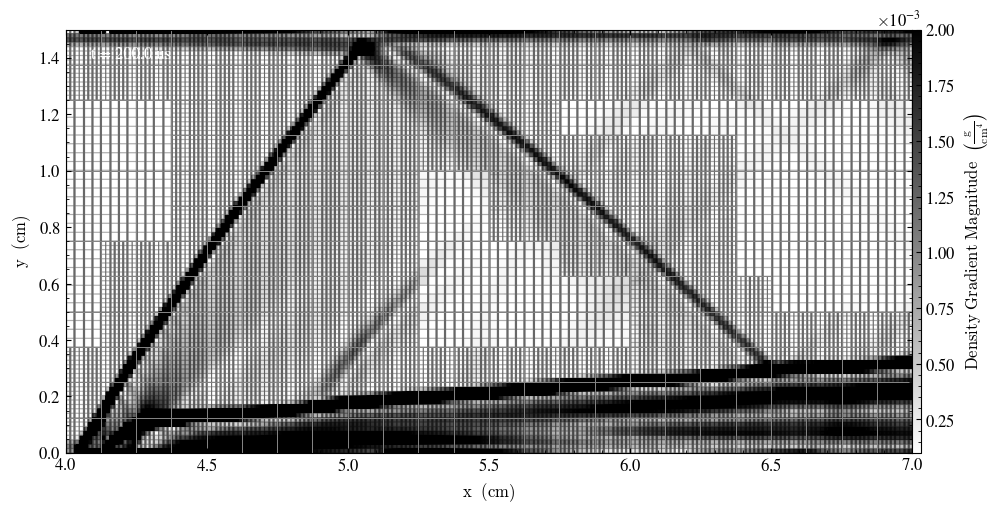

In [2]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import AxesGrid
import yt
import os


fns = [
    #"plt125000",
    #"plt15604",
    #"plt16696",
    #"plt23116",
    #"AMRL2/plt22876"
    #"jinJISCF/m112gs/plt23761"
    "jinJISCF/v26726/plt23354"
    
]


def _laplacian(field, data):
    dp_dx = data[("density_gradient_x_gradient_x")]
    dp_dy = data[("density_gradient_y_gradient_y")]
    dp_dz = data[("density_gradient_z_gradient_z")]
    density_laplacian = dp_dx + dp_dy+ dp_dz
    return density_laplacian


fig = plt.figure(figsize=(6*8.4, 3*8.4))
grid = AxesGrid(
    fig,
    (0.06, 0.1, 0.85, 0.85),
    nrows_ncols=(1, 1),
    axes_pad=0.00,
    label_mode="1",
    share_all=True,
    cbar_location="right",
    cbar_mode="single",
    cbar_size="1%",
    cbar_pad="0%",
)

field = "density_gradient_magnitude"

for i, fn in enumerate(fns):
    ds = yt.load(fn)

    
    ds.add_gradient_fields(("density"))
    ds.add_gradient_fields(("density_gradient_x"))
    ds.add_gradient_fields(("density_gradient_y"))
    ds.add_gradient_fields(("density_gradient_z"))

   
    ds.add_field(("boxlib", "laplacian"), function=_laplacian,
                 display_name="Schlieren",
                 sampling_type="cell")

    ds.force_periodicity()

    slc = yt.SlicePlot(ds, "z", field, origin = "native")
    pan = (-0.75,0)
    slc.set_width((3, 1.5))
    slc.pan(pan)
    slc.set_font({"size":12})
    slc.set_log((field), False)

    
    slc.annotate_timestamp(corner="upper_left")

    colors = ["black", "dimgray", "darkgray", "gray"]
    for level, color in enumerate(colors):
        slc.annotate_grids(max_level=level, edgecolors=color, linewidth=0.5, alpha=0.9)
        slc.annotate_cell_edges(line_width=0.00001, alpha=0.2)   
    #slc.annotate_grids()
    
    #slc.annotate_cell_edges(linewidth=0.5, alpha=0.7)
    #slc.set_cmap((field), cmap="coolwarm")
    slc.set_cmap(field, cmap="binary")
    slc.set_zlim((field), zmin=(0.1e-3), zmax=(2e-3))

    # Assign to Matplotlib figure grid
    plot = slc.plots[field]
    plot.figure = fig
    plot.axes = grid[i].axes
    plot.cax = grid.cbar_axes[i]

    # Render the plot
    slc.render()


#plt.savefig("numericalschlieren.png", dpi=400)
plt.show()


yt : [INFO     ] 2026-07-28 10:04:10,331 Parameters: current_time              = 0.0002
yt : [INFO     ] 2026-07-28 10:04:10,332 Parameters: domain_dimensions         = [400  48  16]
yt : [INFO     ] 2026-07-28 10:04:10,333 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-07-28 10:04:10,334 Parameters: domain_right_edge         = [12.5  1.5  0.5]
yt : [INFO     ] 2026-07-28 10:04:22,697 xlim = 0.000000 12.500000
yt : [INFO     ] 2026-07-28 10:04:22,697 ylim = 0.000000 1.500000
yt : [INFO     ] 2026-07-28 10:04:22,700 xlim = 0.000000 12.500000
yt : [INFO     ] 2026-07-28 10:04:22,700 ylim = 0.000000 1.500000
yt : [INFO     ] 2026-07-28 10:04:22,704 Making a fixed resolution buffer of (('gas', 'density_gradient_magnitude')) 800 by 800


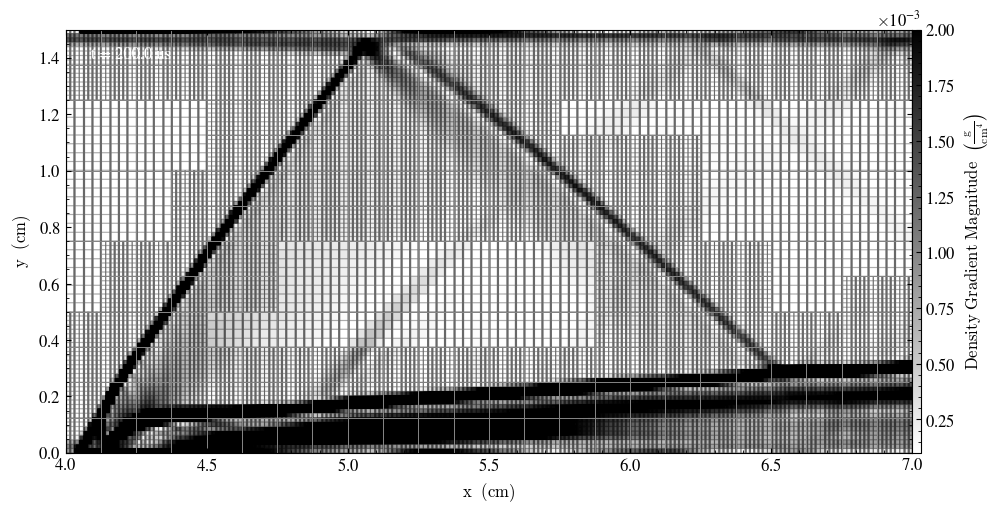

In [1]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import AxesGrid
import yt
import os


fns = [
    #"plt125000",
    #"plt15604",
    #"plt16696",
    #"plt23116",
    #"AMRL2/plt22876"
    #"jinJISCF/m112gs/plt23761"
    #"jinJISCF/v26726/plt23354"
    "jinJISCF/jetMachBC/plt17652"
    
]


def _laplacian(field, data):
    dp_dx = data[("density_gradient_x_gradient_x")]
    dp_dy = data[("density_gradient_y_gradient_y")]
    dp_dz = data[("density_gradient_z_gradient_z")]
    density_laplacian = dp_dx + dp_dy+ dp_dz
    return density_laplacian


fig = plt.figure(figsize=(6*8.4, 3*8.4))
grid = AxesGrid(
    fig,
    (0.06, 0.1, 0.85, 0.85),
    nrows_ncols=(1, 1),
    axes_pad=0.00,
    label_mode="1",
    share_all=True,
    cbar_location="right",
    cbar_mode="single",
    cbar_size="1%",
    cbar_pad="0%",
)

field = "density_gradient_magnitude"

for i, fn in enumerate(fns):
    ds = yt.load(fn)

    
    ds.add_gradient_fields(("density"))
    ds.add_gradient_fields(("density_gradient_x"))
    ds.add_gradient_fields(("density_gradient_y"))
    ds.add_gradient_fields(("density_gradient_z"))

   
    ds.add_field(("boxlib", "laplacian"), function=_laplacian,
                 display_name="Schlieren",
                 sampling_type="cell")

    ds.force_periodicity()

    slc = yt.SlicePlot(ds, "z", field, origin = "native")
    pan = (-0.75,0)
    slc.set_width((3, 1.5))
    slc.pan(pan)
    slc.set_font({"size":12})
    slc.set_log((field), False)

    
    slc.annotate_timestamp(corner="upper_left")

    colors = ["black", "dimgray", "darkgray", "gray"]
    for level, color in enumerate(colors):
        slc.annotate_grids(max_level=level, edgecolors=color, linewidth=0.5, alpha=0.9)
        slc.annotate_cell_edges(line_width=0.00001, alpha=0.2)   
    #slc.annotate_grids()
    
    #slc.annotate_cell_edges(linewidth=0.5, alpha=0.7)
    #slc.set_cmap((field), cmap="coolwarm")
    slc.set_cmap(field, cmap="binary")
    slc.set_zlim((field), zmin=(0.1e-3), zmax=(2e-3))

    # Assign to Matplotlib figure grid
    plot = slc.plots[field]
    plot.figure = fig
    plot.axes = grid[i].axes
    plot.cax = grid.cbar_axes[i]

    # Render the plot
    slc.render()


#plt.savefig("numericalschlieren.png", dpi=400)
plt.show()


yt : [INFO     ] 2026-07-28 10:04:49,949 Parameters: current_time              = 0.0002
yt : [INFO     ] 2026-07-28 10:04:49,950 Parameters: domain_dimensions         = [400  48  16]
yt : [INFO     ] 2026-07-28 10:04:49,951 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-07-28 10:04:49,952 Parameters: domain_right_edge         = [12.5  1.5  0.5]
yt : [INFO     ] 2026-07-28 10:04:49,994 Parameters: current_time              = 0.0002
yt : [INFO     ] 2026-07-28 10:04:49,995 Parameters: domain_dimensions         = [400  48  16]
yt : [INFO     ] 2026-07-28 10:04:49,996 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-07-28 10:04:49,997 Parameters: domain_right_edge         = [12.5  1.5  0.5]


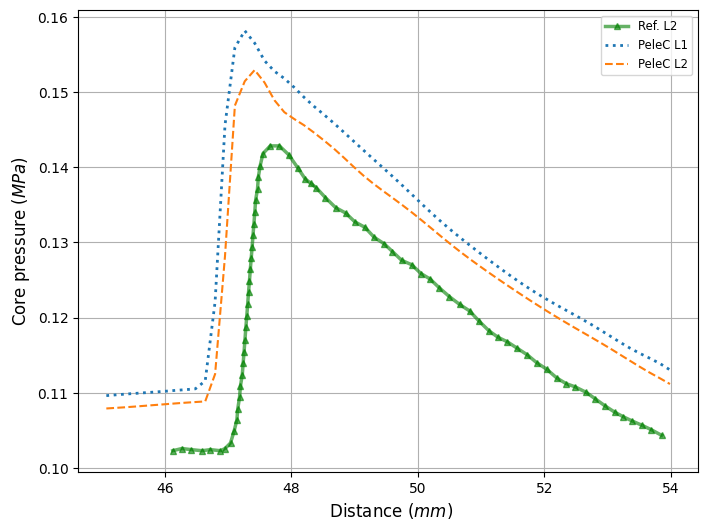

In [2]:
# Profile
# Extract lines

import yt
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Load the datasets

#03 - perfil uniforme
#04 - perfil parabolico turbulento
#05 - perfil uniforme mec. BurkeDryer
#06 - perfil parabolico laminar

#ds = yt.load("plt19355")  # Pressure 800 000
#ds = yt.load("plt105000")  # Non-reactive/AMR-L2
#ds = yt.load("plt17199")  # Pressure 993 000
#ds = yt.load("plt32810")  # Pres_amb 1 000 000 
#ds2 = yt.load("plt16267")  # 
#ds = yt.load("pltRVPL1")  #

#ds = yt.load("plt95k004")  # nuevo L2
#ds = yt.load("plt35k007")  # nuevo L2
#ds = yt.load("plt15604")  # nuevo L2


#ds = yt.load("AMRL2/plt22876")
ds = yt.load("jinJISCF/m112gs/plt23761")


#ds = yt.load("plt105000")  # nuevo L2
#ds = yt.load("plt193k006")  # nuevo L2
#ds = yt.load("plt70k006")  # nuevo L2
#ds = yt.load("plt15000")  #
#ds2 = yt.load("pltrectprofvel95k")  # 
 
#ds2 = yt.load("pltRVPL2")  # 
#ds2 = yt.load("plt45000")  # nuevo L1
#ds2 = yt.load("plt147k003")  # nuevo L2
#ds2 = yt.load("plt16696")  # nuevo L3
#ds2 = yt.load("plt23116")  # nuevo L3

#ds2 = yt.load("jinJISCF/m112gs/plt23761")
#ds2 = yt.load("jinJISCF/v26726/plt23354")
ds2 = yt.load("jinJISCF/jetMachBC/plt17652")

#ds = yt.load("plt90000old")  #old
#ds2 = yt.load("plt95000")  # yo2=0.233
#ds2 = yt.load("plt90000")  # nuevo perfil 
#ds2 = yt.load("plt20432")  # No velocity profile
#ds2 = yt.load("plt40000")  # Non-reactive/AMR-L4
# Define the start and end points for the line along the x-direction
# centro de eje y-z
start_point = [4.5, 0.98, 0.25] 
end_point = [5.4, 0.98, 0.25]
#start_point = [4.4, 1.02, 0.25] 
#end_point = [5.3, 1.02, 0.25]
#start_point = [4.4, 0.95, 0.25] 
#end_point = [5.3, 0.95, 0.25]

# From inputs file:
# geometry.prob_lo     =   0.0  0.0   0.0
# geometry.prob_hi     =   12.5  1.5   0.5

# Create the ray along the y-axis
ray = ds.ray(start_point, end_point)
ray2 = ds2.ray(start_point, end_point)

# Extract the data from the line along the y-axis
x_coordinates = ray["x"]
data_to_plot_pres = ray["pressure"]
x_coordinates2 = ray2["x"]
data_to_plot_pres2 = ray2["pressure"]
#data_to_plot_vel = ray["x_velocity"]

#print("x_positions size:", len(x_positions))
#print("values size:", len(values))

# Convert to numpy arrays
x_positions = np.array(x_coordinates)
values = np.array(data_to_plot_pres)
x_positions2 = np.array(x_coordinates2)
values2 = np.array(data_to_plot_pres2)

# Sort the data by x positions
sorted_indices = np.argsort(x_positions)
sorted_x_positions = x_positions[sorted_indices]
sorted_values = values[sorted_indices]
sorted_indices2 = np.argsort(x_positions2)
sorted_x_positions2 = x_positions2[sorted_indices2]
sorted_values2 = values2[sorted_indices2]


#REF DATA
df_pres = pd.read_csv('presRefL2.csv')

# Create the plots
fig, (ax1) = plt.subplots(1, figsize=(8, 6))

# Temperature plot
ax1.plot(df_pres.iloc[:, 0] , df_pres.iloc[:, 1], label=r"Ref. L2", color="g", lw=2.5, marker='^', ms=4, alpha=0.6)

ax1.plot(sorted_x_positions / 0.1, sorted_values*1E-07, label=r"PeleC L1", linestyle=':', linewidth=2)
ax1.plot(sorted_x_positions2 / 0.1, sorted_values2*1E-07, label=r"PeleC L2", linestyle='--')

ax1.set_xlabel(" Distance $(mm)$", fontsize=12)
ax1.set_ylabel(r"Core pressure $(MPa)$", fontsize=12)
ax1.legend(fontsize='small')
ax1.grid(True)
#plt.tight_layout()
#plt.savefig('plot1.png', dpi=400)  # Save the figure in high quality
plt.show()

yt : [INFO     ] 2026-07-13 12:25:37,897 Parameters: current_time              = 0.0002
yt : [INFO     ] 2026-07-13 12:25:37,899 Parameters: domain_dimensions         = [400  48  16]
yt : [INFO     ] 2026-07-13 12:25:37,900 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-07-13 12:25:37,901 Parameters: domain_right_edge         = [12.5  1.5  0.5]


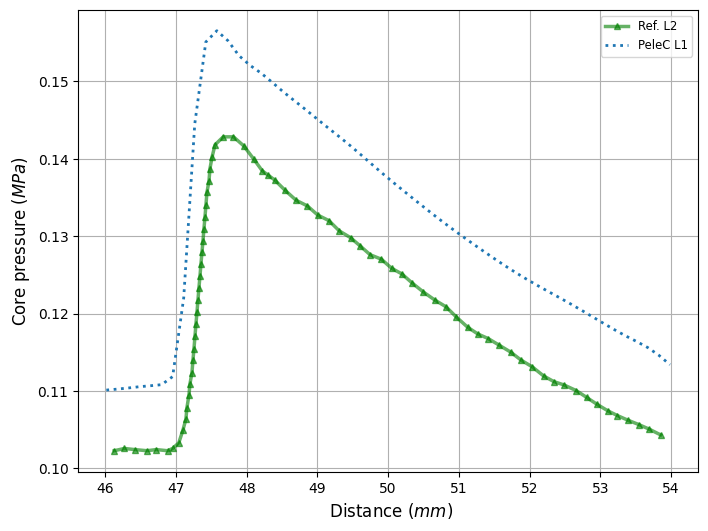

In [7]:
# Profile
# Extract lines

import yt
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Load the datasets


 
#ds = yt.load("plt15604")  # 
ds = yt.load("AMRL2/plt22876")
#ds2 = yt.load("plt45000")  # nuevo L1
#ds= yt.load("plt124554")  # nuevo L2
#ds = yt.load("plt90000old")  #old
#ds2 = yt.load("plt95000")  # yo2=0.233
#ds2 = yt.load("plt90000")  # nuevo perfil 
#ds2 = yt.load("plt20432")  # No velocity profile
#ds2 = yt.load("plt40000")  # Non-reactive/AMR-L4
# Define the start and end points for the line along the x-direction
# centro de eje y-z
start_point = [4.6, 1.01, 0.25] 
end_point = [5.4, 1.01, 0.25]
#start_point = [4.5, 0.75, 0.25] 
#end_point = [5.4, 0.75, 0.25]

# From inputs file:
# geometry.prob_lo     =   0.0  0.0   0.0
# geometry.prob_hi     =   12.5  1.5   0.5

# Create the ray along the y-axis
ray = ds.ray(start_point, end_point)


# Extract the data from the line along the y-axis
x_coordinates = ray["x"]
data_to_plot_pres = ray["pressure"]


#print("x_positions size:", len(x_positions))
#print("values size:", len(values))

# Convert to numpy arrays
x_positions = np.array(x_coordinates)
values = np.array(data_to_plot_pres)


# Sort the data by x positions
sorted_indices = np.argsort(x_positions)
sorted_x_positions = x_positions[sorted_indices]
sorted_values = values[sorted_indices]



#REF DATA
df_pres = pd.read_csv('presRefL2.csv')

# Create the plots
fig, (ax1) = plt.subplots(1, figsize=(8, 6))

# Temperature plot
ax1.plot(df_pres.iloc[:, 0] , df_pres.iloc[:, 1], label=r"Ref. L2", color="g", lw=2.5, marker='^', ms=4, alpha=0.6)

ax1.plot(sorted_x_positions / 0.1, sorted_values*1E-07, label=r"PeleC L1", linestyle=':', linewidth=2)


ax1.set_xlabel(" Distance $(mm)$", fontsize=12)
ax1.set_ylabel(r"Core pressure $(MPa)$", fontsize=12)
ax1.legend(fontsize='small')
ax1.grid(True)
#plt.tight_layout()
#plt.savefig('plot1.png', dpi=400)  # Save the figure in high quality
plt.show()

yt : [INFO     ] 2026-07-13 12:32:19,464 Parameters: current_time              = 0.0002
yt : [INFO     ] 2026-07-13 12:32:19,466 Parameters: domain_dimensions         = [400  48  16]
yt : [INFO     ] 2026-07-13 12:32:19,467 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-07-13 12:32:19,468 Parameters: domain_right_edge         = [12.5  1.5  0.5]
yt : [INFO     ] 2026-07-13 12:32:19,511 Parameters: current_time              = 0.0002
yt : [INFO     ] 2026-07-13 12:32:19,512 Parameters: domain_dimensions         = [400  48  16]
yt : [INFO     ] 2026-07-13 12:32:19,513 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-07-13 12:32:19,513 Parameters: domain_right_edge         = [12.5  1.5  0.5]


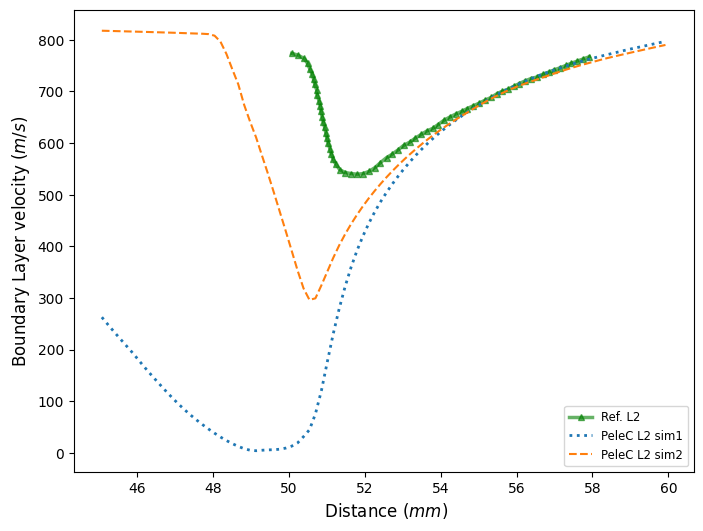

In [20]:
# Profile
# Extract lines

import yt
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Load the datasets

#ds = yt.load("plt15604")  # Non-reactive/AMR-L2
ds = yt.load("AMRL2/plt22876")
ds2 = yt.load("plt23116")  # Non-reactive/AMR-L4

# Define the start and end points for the line along the x-direction
# centro de eje y-z
#start_point = [4.5, 1.47, 0.25] 
#end_point = [6.0, 1.47, 0.25]
#start_point = [4.5, 1.48, 0.25] 
#end_point = [5.8, 1.48, 0.25]

#start_point = [4.5, 1.453125, 0.25] 
#end_point = [6.0, 1.454125, 0.25]

start_point = [4.5, 1.46875, 0.25] 
end_point = [6.0, 1.46875, 0.25]
#start_point = [5.0, 1.484375, 0.25] 
#end_point = [6.0, 1.484375, 0.25]
#start_point = [5.0, 1.5, 0.25] 
#end_point = [6.0, 1.5, 0.25]

#start_point = [4.5, 0.75, 0.25] 
#end_point = [6.0, 0.75, 0.25]

# From inputs file:
# geometry.prob_lo     =   0.0  0.0   0.0
# geometry.prob_hi     =   12.5  1.5   0.5

# Create the ray along the y-axis
ray = ds.ray(start_point, end_point)
ray2 = ds2.ray(start_point, end_point)

# Extract the data from the line along the y-axis
x_coordinates = ray["x"]
#data_to_plot_vel = ray["x_velocity"]
x_coordinates2 = ray2["x"]
#data_to_plot_vel2 = ray2["x_velocity"]


data_to_plot_vel = ray["magvel"]

data_to_plot_vel2 = ray2["magvel"]
#data_to_plot_vel = ray["x_velocity"]

#print("x_positions size:", len(x_positions))
#print("values size:", len(values))

# Convert to numpy arrays
x_positions = np.array(x_coordinates)
values = np.array(data_to_plot_vel)
x_positions2 = np.array(x_coordinates2)
values2 = np.array(data_to_plot_vel2)

# Sort the data by x positions
sorted_indices = np.argsort(x_positions)
sorted_x_positions = x_positions[sorted_indices]
sorted_values = values[sorted_indices]
sorted_indices2 = np.argsort(x_positions2)
sorted_x_positions2 = x_positions2[sorted_indices2]
sorted_values2 = values2[sorted_indices2]


#REF DATA
df_vel = pd.read_csv('BLVelRef.csv')

# Create the plots
fig, (ax1) = plt.subplots(1, figsize=(8, 6))

# Temperature plot
ax1.plot(df_vel.iloc[:, 0] , df_vel.iloc[:, 1], label=r"Ref. L2", color="g", lw=2.5, marker='^', ms=4, alpha=0.6)

ax1.plot(sorted_x_positions / 0.1, sorted_values*1E-02, label=r"PeleC L2 sim1", linestyle=':', linewidth=2)
ax1.plot(sorted_x_positions2 / 0.1, sorted_values2*1E-02, label=r"PeleC L2 sim2", linestyle='--')

#ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))  # Two decimals on x-axis
#ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

ax1.set_xlabel(" Distance $(mm)$", fontsize=12)
ax1.set_ylabel(r"Boundary Layer velocity $(m/s)$", fontsize=12)
ax1.legend(fontsize='small')
#plt.tight_layout()
#plt.savefig('plot1.png', dpi=400)  # Save the figure in high quality
plt.show()

yt : [INFO     ] 2026-07-13 12:32:00,080 Parameters: current_time              = 0.0002
yt : [INFO     ] 2026-07-13 12:32:00,081 Parameters: domain_dimensions         = [400  48  16]
yt : [INFO     ] 2026-07-13 12:32:00,083 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-07-13 12:32:00,083 Parameters: domain_right_edge         = [12.5  1.5  0.5]
yt : [INFO     ] 2026-07-13 12:32:00,118 Parameters: current_time              = 0.0002
yt : [INFO     ] 2026-07-13 12:32:00,120 Parameters: domain_dimensions         = [400  48  16]
yt : [INFO     ] 2026-07-13 12:32:00,121 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-07-13 12:32:00,121 Parameters: domain_right_edge         = [12.5  1.5  0.5]


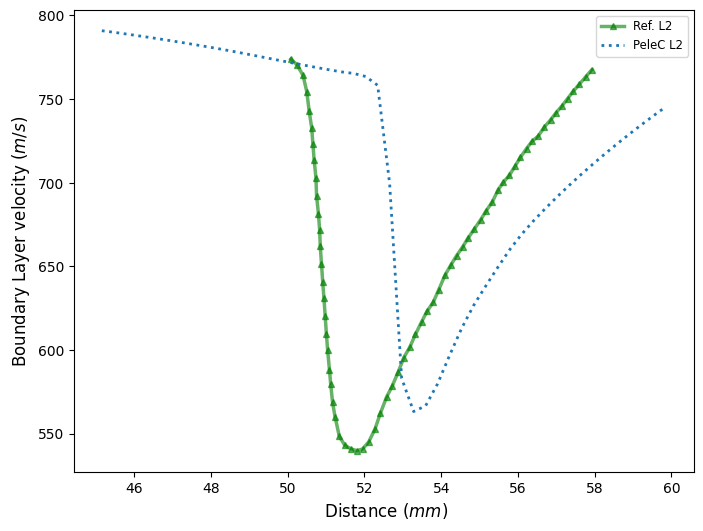

In [19]:
# Profile
# Extract lines

import yt
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Load the datasets

ds = yt.load("plt15604")  # Non-reactive/AMR-L2
ds2 = yt.load("plt15604")  # Non-reactive/AMR-L4

# Define the start and end points for the line along the x-direction
# centro de eje y-z
#start_point = [4.5, 1.47, 0.25] 
#end_point = [6.0, 1.47, 0.25]
#start_point = [4.5, 1.48, 0.25] 
#end_point = [5.8, 1.48, 0.25]

#start_point = [4.5, 1.453125, 0.25] 
#end_point = [6.0, 1.454125, 0.25]

start_point = [4.5, 1.46875, 0.25] 
end_point = [6.0, 1.46875, 0.25]
#start_point = [5.0, 1.484375, 0.25] 
#end_point = [6.0, 1.484375, 0.25]
#start_point = [5.0, 1.5, 0.25] 
#end_point = [6.0, 1.5, 0.25]

#start_point = [4.5, 0.75, 0.25] 
#end_point = [6.0, 0.75, 0.25]

# From inputs file:
# geometry.prob_lo     =   0.0  0.0   0.0
# geometry.prob_hi     =   12.5  1.5   0.5

# Create the ray along the y-axis
ray = ds.ray(start_point, end_point)
ray2 = ds2.ray(start_point, end_point)

# Extract the data from the line along the y-axis
x_coordinates = ray["x"]
#data_to_plot_vel = ray["x_velocity"]
x_coordinates2 = ray2["x"]
#data_to_plot_vel2 = ray2["x_velocity"]


data_to_plot_vel = ray["magvel"]

data_to_plot_vel2 = ray2["magvel"]
#data_to_plot_vel = ray["x_velocity"]

#print("x_positions size:", len(x_positions))
#print("values size:", len(values))

# Convert to numpy arrays
x_positions = np.array(x_coordinates)
values = np.array(data_to_plot_vel)
x_positions2 = np.array(x_coordinates2)
values2 = np.array(data_to_plot_vel2)

# Sort the data by x positions
sorted_indices = np.argsort(x_positions)
sorted_x_positions = x_positions[sorted_indices]
sorted_values = values[sorted_indices]
sorted_indices2 = np.argsort(x_positions2)
sorted_x_positions2 = x_positions2[sorted_indices2]
sorted_values2 = values2[sorted_indices2]


#REF DATA
df_vel = pd.read_csv('BLVelRef.csv')

# Create the plots
fig, (ax1) = plt.subplots(1, figsize=(8, 6))

# Temperature plot
ax1.plot(df_vel.iloc[:, 0] , df_vel.iloc[:, 1], label=r"Ref. L2", color="g", lw=2.5, marker='^', ms=4, alpha=0.6)

ax1.plot(sorted_x_positions / 0.1, sorted_values*1E-02, label=r"PeleC L2", linestyle=':', linewidth=2)


#ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))  # Two decimals on x-axis
#ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

ax1.set_xlabel(" Distance $(mm)$", fontsize=12)
ax1.set_ylabel(r"Boundary Layer velocity $(m/s)$", fontsize=12)
ax1.legend(fontsize='small')
#plt.tight_layout()
#plt.savefig('plot1.png', dpi=400)  # Save the figure in high quality
plt.show()

yt : [INFO     ] 2025-05-15 10:23:28,664 Parameters: current_time              = 0.0003340696101508976
yt : [INFO     ] 2025-05-15 10:23:28,665 Parameters: domain_dimensions         = [400  48  16]
yt : [INFO     ] 2025-05-15 10:23:28,666 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-05-15 10:23:28,667 Parameters: domain_right_edge         = [12.5  1.5  0.5]
yt : [INFO     ] 2025-05-15 10:23:28,710 Parameters: current_time              = 0.0014
yt : [INFO     ] 2025-05-15 10:23:28,712 Parameters: domain_dimensions         = [400  48  16]
yt : [INFO     ] 2025-05-15 10:23:28,713 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-05-15 10:23:28,714 Parameters: domain_right_edge         = [12.5  1.5  0.5]


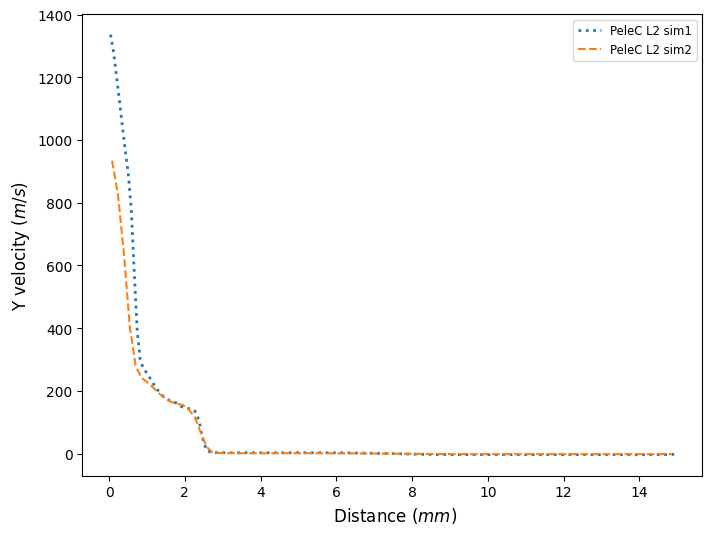

In [4]:
# Profile
# Extract lines

import yt
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Load the datasets

ds = yt.load("pltAden30k")  # Non-reactive/AMR-L2
#ds = yt.load("plt77719")  # Non-reactive/AMR-L2
ds2 = yt.load("plt147k003")  # Non-reactive/AMR-L4

# Define the start and end points for the line along the x-direction
# centro de eje y-z

start_point = [4.2, 0, 0.25] 
end_point = [4.2, 1.5, 0.25]
#start_point = [5.0, 1.484375, 0.25] 
#end_point = [6.0, 1.484375, 0.25]
#start_point = [5.0, 1.5, 0.25] 
#end_point = [6.0, 1.5, 0.25]

# From inputs file:
# geometry.prob_lo     =   0.0  0.0   0.0
# geometry.prob_hi     =   12.5  1.5   0.5

# Create the ray along the y-axis
ray = ds.ray(start_point, end_point)
ray2 = ds2.ray(start_point, end_point)

# Extract the data from the line along the y-axis
x_coordinates = ray["y"]
data_to_plot_vel = ray["y_velocity"]
#data_to_plot_vel = ray["MachNumber"]
x_coordinates2 = ray2["y"]
data_to_plot_vel2 = ray2["y_velocity"]
#data_to_plot_vel2 = ray2["MachNumber"]
#data_to_plot_vel = ray["x_velocity"]

#print("x_positions size:", len(x_positions))
#print("values size:", len(values))

# Convert to numpy arrays
x_positions = np.array(x_coordinates)
values = np.array(data_to_plot_vel)
x_positions2 = np.array(x_coordinates2)
values2 = np.array(data_to_plot_vel2)

# Sort the data by x positions
sorted_indices = np.argsort(x_positions)
sorted_x_positions = x_positions[sorted_indices]
sorted_values = values[sorted_indices]
sorted_indices2 = np.argsort(x_positions2)
sorted_x_positions2 = x_positions2[sorted_indices2]
sorted_values2 = values2[sorted_indices2]


#REF DATA
#df_vel = pd.read_csv('BLVelRef.csv')

# Create the plots
fig, (ax1) = plt.subplots(1, figsize=(8, 6))

# Temperature plot
#ax1.plot(df_vel.iloc[:, 0] , df_vel.iloc[:, 1], label=r"Ref. L2", color="g", lw=2.5, marker='^', ms=4, alpha=0.6)

ax1.plot(sorted_x_positions / 0.1, sorted_values*1E-02, label=r"PeleC L2 sim1", linestyle=':', linewidth=2)
ax1.plot(sorted_x_positions2 / 0.1, sorted_values2*1E-02, label=r"PeleC L2 sim2", linestyle='--')

#ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))  # Two decimals on x-axis
#ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

ax1.set_xlabel(" Distance $(mm)$", fontsize=12)
ax1.set_ylabel(r"Y velocity $(m/s)$", fontsize=12)
ax1.legend(fontsize='small')
#plt.tight_layout()
#plt.savefig('plot1.png', dpi=400)  # Save the figure in high quality
plt.show()

yt : [INFO     ] 2025-05-13 10:37:40,866 Parameters: current_time              = 0.0009434279203564942
yt : [INFO     ] 2025-05-13 10:37:40,866 Parameters: domain_dimensions         = [400  48  16]
yt : [INFO     ] 2025-05-13 10:37:40,867 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-05-13 10:37:40,868 Parameters: domain_right_edge         = [12.5  1.5  0.5]
yt : [INFO     ] 2025-05-13 10:37:40,908 Parameters: current_time              = 0.000977298408532304
yt : [INFO     ] 2025-05-13 10:37:40,909 Parameters: domain_dimensions         = [400  48  16]
yt : [INFO     ] 2025-05-13 10:37:40,909 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-05-13 10:37:40,910 Parameters: domain_right_edge         = [12.5  1.5  0.5]


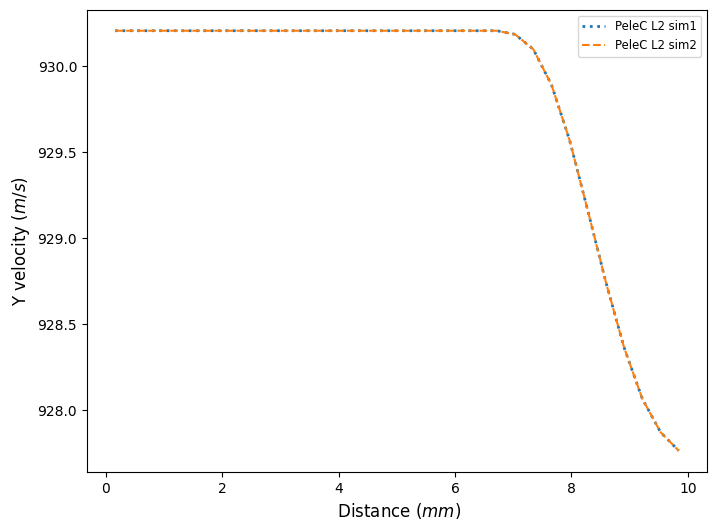

In [9]:
# Profile
# Extract lines

import yt
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Load the datasets

ds = yt.load("plt95k003")  # Non-reactive/AMR-L2
#ds = yt.load("plt77719")  # Non-reactive/AMR-L2
ds2 = yt.load("plt90kn7")  # Non-reactive/AMR-L4

# Define the start and end points for the line along the x-direction
# centro de eje y-z

start_point = [0.0, 0.75, 0.25] 
end_point = [1.0, 0.75, 0.25]
#start_point = [5.0, 1.484375, 0.25] 
#end_point = [6.0, 1.484375, 0.25]
#start_point = [5.0, 1.5, 0.25] 
#end_point = [6.0, 1.5, 0.25]

# From inputs file:
# geometry.prob_lo     =   0.0  0.0   0.0
# geometry.prob_hi     =   12.5  1.5   0.5

# Create the ray along the y-axis
ray = ds.ray(start_point, end_point)
ray2 = ds2.ray(start_point, end_point)

# Extract the data from the line along the y-axis
x_coordinates = ray["x"]
data_to_plot_vel = ray["x_velocity"]
#data_to_plot_vel = ray["MachNumber"]
x_coordinates2 = ray2["x"]
data_to_plot_vel2 = ray2["x_velocity"]
#data_to_plot_vel2 = ray2["MachNumber"]
#data_to_plot_vel = ray["x_velocity"]

#print("x_positions size:", len(x_positions))
#print("values size:", len(values))

# Convert to numpy arrays
x_positions = np.array(x_coordinates)
values = np.array(data_to_plot_vel)
x_positions2 = np.array(x_coordinates2)
values2 = np.array(data_to_plot_vel2)

# Sort the data by x positions
sorted_indices = np.argsort(x_positions)
sorted_x_positions = x_positions[sorted_indices]
sorted_values = values[sorted_indices]
sorted_indices2 = np.argsort(x_positions2)
sorted_x_positions2 = x_positions2[sorted_indices2]
sorted_values2 = values2[sorted_indices2]


#REF DATA
#df_vel = pd.read_csv('BLVelRef.csv')

# Create the plots
fig, (ax1) = plt.subplots(1, figsize=(8, 6))

# Temperature plot
#ax1.plot(df_vel.iloc[:, 0] , df_vel.iloc[:, 1], label=r"Ref. L2", color="g", lw=2.5, marker='^', ms=4, alpha=0.6)

ax1.plot(sorted_x_positions / 0.1, sorted_values*1E-02, label=r"PeleC L2 sim1", linestyle=':', linewidth=2)
ax1.plot(sorted_x_positions2 / 0.1, sorted_values2*1E-02, label=r"PeleC L2 sim2", linestyle='--')

#ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))  # Two decimals on x-axis
#ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

ax1.set_xlabel(" Distance $(mm)$", fontsize=12)
ax1.set_ylabel(r"Y velocity $(m/s)$", fontsize=12)
ax1.legend(fontsize='small')
#plt.tight_layout()
#plt.savefig('plot1.png', dpi=400)  # Save the figure in high quality
plt.show()

yt : [INFO     ] 2025-05-15 10:26:12,436 Parameters: current_time              = 0.0010236931368815968
yt : [INFO     ] 2025-05-15 10:26:12,438 Parameters: domain_dimensions         = [400  48  16]
yt : [INFO     ] 2025-05-15 10:26:12,438 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-05-15 10:26:12,439 Parameters: domain_right_edge         = [12.5  1.5  0.5]
yt : [INFO     ] 2025-05-15 10:26:12,479 Parameters: current_time              = 0.0014
yt : [INFO     ] 2025-05-15 10:26:12,481 Parameters: domain_dimensions         = [400  48  16]
yt : [INFO     ] 2025-05-15 10:26:12,482 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-05-15 10:26:12,483 Parameters: domain_right_edge         = [12.5  1.5  0.5]


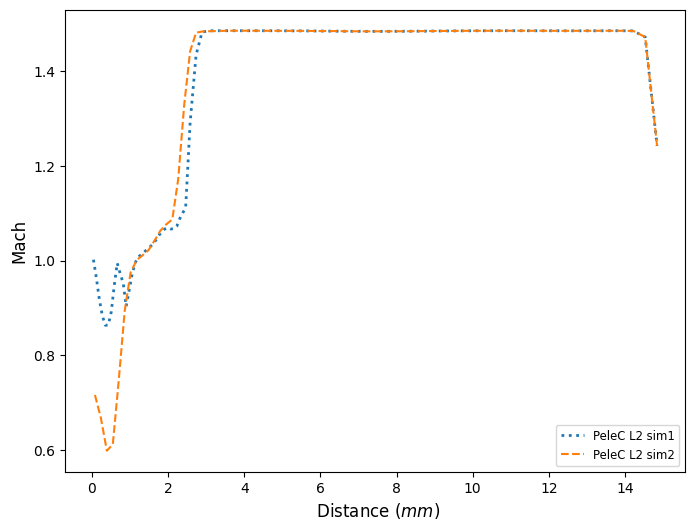

In [6]:
# Profile
# Extract lines

import yt
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Load the datasets

#ds = yt.load("plt70000")  # Non-reactive/AMR-L2
ds = yt.load("pltRVPL1")  # Non-reactive/AMR-L2
ds2 = yt.load("plt147k003")  # Non-reactive/AMR-L4

# Define the start and end points for the line along the x-direction
# centro de eje y-z

start_point = [4.2, 0, 0.25] 
end_point = [4.2, 1.5, 0.25]
#start_point = [5.0, 1.484375, 0.25] 
#end_point = [6.0, 1.484375, 0.25]
#start_point = [5.0, 1.5, 0.25] 
#end_point = [6.0, 1.5, 0.25]

# From inputs file:
# geometry.prob_lo     =   0.0  0.0   0.0
# geometry.prob_hi     =   12.5  1.5   0.5

# Create the ray along the y-axis
ray = ds.ray(start_point, end_point)
ray2 = ds2.ray(start_point, end_point)

# Extract the data from the line along the y-axis
x_coordinates = ray["y"]
#data_to_plot_vel = ray["y_velocity"]
data_to_plot_vel = ray["MachNumber"]
x_coordinates2 = ray2["y"]
#data_to_plot_vel2 = ray2["y_velocity"]
data_to_plot_vel2 = ray2["MachNumber"]
#data_to_plot_vel = ray["x_velocity"]

#print("x_positions size:", len(x_positions))
#print("values size:", len(values))

# Convert to numpy arrays
x_positions = np.array(x_coordinates)
values = np.array(data_to_plot_vel)
x_positions2 = np.array(x_coordinates2)
values2 = np.array(data_to_plot_vel2)

# Sort the data by x positions
sorted_indices = np.argsort(x_positions)
sorted_x_positions = x_positions[sorted_indices]
sorted_values = values[sorted_indices]
sorted_indices2 = np.argsort(x_positions2)
sorted_x_positions2 = x_positions2[sorted_indices2]
sorted_values2 = values2[sorted_indices2]


#REF DATA
#df_vel = pd.read_csv('BLVelRef.csv')

# Create the plots
fig, (ax1) = plt.subplots(1, figsize=(8, 6))

# Temperature plot
#ax1.plot(df_vel.iloc[:, 0] , df_vel.iloc[:, 1], label=r"Ref. L2", color="g", lw=2.5, marker='^', ms=4, alpha=0.6)

ax1.plot(sorted_x_positions / 0.1, sorted_values, label=r"PeleC L2 sim1", linestyle=':', linewidth=2)
ax1.plot(sorted_x_positions2 / 0.1, sorted_values2, label=r"PeleC L2 sim2", linestyle='--')

#ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))  # Two decimals on x-axis
#ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

ax1.set_xlabel(" Distance $(mm)$", fontsize=12)
ax1.set_ylabel(r"Mach", fontsize=12)
ax1.legend(fontsize='small')
#plt.tight_layout()
#plt.savefig('plot1.png', dpi=400)  # Save the figure in high quality
plt.show()

In [11]:
# Profile
# Extract lines

import yt
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Load the datasets

#ds = yt.load("plt19355")  # Non-reactive/AMR-L2
ds = yt.load("plt77719")  # Non-reactive/AMR-L2
ds2 = yt.load("plt80000")  # Non-reactive/AMR-L4

# Define the start and end points for the line along the x-direction
# centro de eje y-z

start_point = [4.2, 0, 0.25] 
end_point = [4.2, 1.5, 0.25]
#start_point = [5.0, 1.484375, 0.25] 
#end_point = [6.0, 1.484375, 0.25]
#start_point = [5.0, 1.5, 0.25] 
#end_point = [6.0, 1.5, 0.25]

# From inputs file:
# geometry.prob_lo     =   0.0  0.0   0.0
# geometry.prob_hi     =   12.5  1.5   0.5

# Create the ray along the y-axis
ray = ds.ray(start_point, end_point)
ray2 = ds2.ray(start_point, end_point)

# Extract the data from the line along the y-axis
x_coordinates = ray["y"]
#data_to_plot_vel = ray["y_velocity"]
data_to_plot_vel = ray["pressure"]
x_coordinates2 = ray2["y"]
#data_to_plot_vel2 = ray2["y_velocity"]
data_to_plot_vel2 = ray2["pressure"]
#data_to_plot_vel = ray["x_velocity"]

#print("x_positions size:", len(x_positions))
#print("values size:", len(values))

# Convert to numpy arrays
x_positions = np.array(x_coordinates)
values = np.array(data_to_plot_vel)
x_positions2 = np.array(x_coordinates2)
values2 = np.array(data_to_plot_vel2)

# Sort the data by x positions
sorted_indices = np.argsort(x_positions)
sorted_x_positions = x_positions[sorted_indices]
sorted_values = values[sorted_indices]
sorted_indices2 = np.argsort(x_positions2)
sorted_x_positions2 = x_positions2[sorted_indices2]
sorted_values2 = values2[sorted_indices2]


#REF DATA
#df_vel = pd.read_csv('BLVelRef.csv')

# Create the plots
fig, (ax1) = plt.subplots(1, figsize=(8, 6))

# Temperature plot
#ax1.plot(df_vel.iloc[:, 0] , df_vel.iloc[:, 1], label=r"Ref. L2", color="g", lw=2.5, marker='^', ms=4, alpha=0.6)

ax1.plot(sorted_x_positions / 0.1, sorted_values*1E-06, label=r"PeleC L2 sim1", linestyle=':', linewidth=2)
ax1.plot(sorted_x_positions2 / 0.1, sorted_values2*1E-06, label=r"PeleC L2 sim2", linestyle='--')

#ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))  # Two decimals on x-axis
#ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

ax1.set_xlabel(" Distance $(mm)$", fontsize=12)
ax1.set_ylabel(r"pressure $(atm)$", fontsize=12)
ax1.legend(fontsize='small')
#plt.tight_layout()
#plt.savefig('plot1.png', dpi=400)  # Save the figure in high quality
plt.show()

yt : [INFO     ] 2025-05-13 10:38:19,094 Parameters: current_time              = 0.0014
yt : [INFO     ] 2025-05-13 10:38:19,095 Parameters: domain_dimensions         = [400  48  16]
yt : [INFO     ] 2025-05-13 10:38:19,096 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-05-13 10:38:19,097 Parameters: domain_right_edge         = [12.5  1.5  0.5]
/home/sruiz/.local/lib/python3.10/site-packages/yt/sample_data/api.py:149: UserWarning: Storage directory from yt config doesn't exist (currently set to '/does/not/exist'). Current working directory will be used instead.
  warn(


FileNotFoundError: No such file or directory: 'plt80000'.

yt : [INFO     ] 2024-12-27 07:06:09,842 Parameters: current_time              = 0.0009374925057106742
yt : [INFO     ] 2024-12-27 07:06:09,843 Parameters: domain_dimensions         = [400  48  16]
yt : [INFO     ] 2024-12-27 07:06:09,844 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2024-12-27 07:06:09,845 Parameters: domain_right_edge         = [12.5  1.5  0.5]
yt : [INFO     ] 2024-12-27 07:06:09,886 Parameters: current_time              = 0.0012041260384508142
yt : [INFO     ] 2024-12-27 07:06:09,887 Parameters: domain_dimensions         = [400  48  16]
yt : [INFO     ] 2024-12-27 07:06:09,888 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2024-12-27 07:06:09,889 Parameters: domain_right_edge         = [12.5  1.5  0.5]


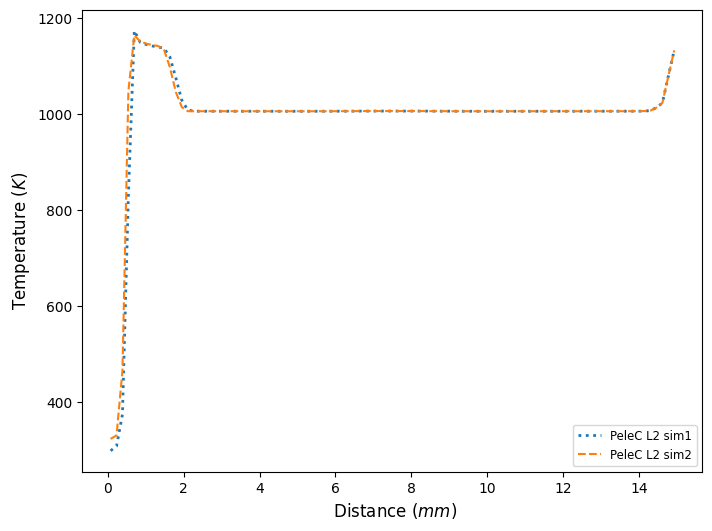

In [7]:
# Profile
# Extract lines

import yt
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Load the datasets

ds = yt.load("plt70000")  # Non-reactive/AMR-L2
#ds = yt.load("plt77719")  # Non-reactive/AMR-L2
ds2 = yt.load("plt90000")  # Non-reactive/AMR-L4

# Define the start and end points for the line along the x-direction
# centro de eje y-z

start_point = [4.2, 0, 0.25] 
end_point = [4.2, 1.5, 0.25]
#start_point = [5.0, 1.484375, 0.25] 
#end_point = [6.0, 1.484375, 0.25]
#start_point = [5.0, 1.5, 0.25] 
#end_point = [6.0, 1.5, 0.25]

# From inputs file:
# geometry.prob_lo     =   0.0  0.0   0.0
# geometry.prob_hi     =   12.5  1.5   0.5

# Create the ray along the y-axis
ray = ds.ray(start_point, end_point)
ray2 = ds2.ray(start_point, end_point)

# Extract the data from the line along the y-axis
x_coordinates = ray["y"]
#data_to_plot_vel = ray["y_velocity"]
data_to_plot_vel = ray["Temp"]
x_coordinates2 = ray2["y"]
#data_to_plot_vel2 = ray2["y_velocity"]
data_to_plot_vel2 = ray2["Temp"]
#data_to_plot_vel = ray["x_velocity"]

#print("x_positions size:", len(x_positions))
#print("values size:", len(values))

# Convert to numpy arrays
x_positions = np.array(x_coordinates)
values = np.array(data_to_plot_vel)
x_positions2 = np.array(x_coordinates2)
values2 = np.array(data_to_plot_vel2)

# Sort the data by x positions
sorted_indices = np.argsort(x_positions)
sorted_x_positions = x_positions[sorted_indices]
sorted_values = values[sorted_indices]
sorted_indices2 = np.argsort(x_positions2)
sorted_x_positions2 = x_positions2[sorted_indices2]
sorted_values2 = values2[sorted_indices2]


#REF DATA
#df_vel = pd.read_csv('BLVelRef.csv')

# Create the plots
fig, (ax1) = plt.subplots(1, figsize=(8, 6))

# Temperature plot
#ax1.plot(df_vel.iloc[:, 0] , df_vel.iloc[:, 1], label=r"Ref. L2", color="g", lw=2.5, marker='^', ms=4, alpha=0.6)

ax1.plot(sorted_x_positions / 0.1, sorted_values, label=r"PeleC L2 sim1", linestyle=':', linewidth=2)
ax1.plot(sorted_x_positions2 / 0.1, sorted_values2, label=r"PeleC L2 sim2", linestyle='--')

#ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))  # Two decimals on x-axis
#ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

ax1.set_xlabel(" Distance $(mm)$", fontsize=12)
ax1.set_ylabel(r"Temperature $(K)$", fontsize=12)
ax1.legend(fontsize='small')
#plt.tight_layout()
#plt.savefig('plot1.png', dpi=400)  # Save the figure in high quality
plt.show()

yt : [INFO     ] 2024-12-26 08:35:22,957 Parameters: current_time              = 0.0006232568351956339
yt : [INFO     ] 2024-12-26 08:35:22,959 Parameters: domain_dimensions         = [400  48  16]
yt : [INFO     ] 2024-12-26 08:35:22,960 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2024-12-26 08:35:22,961 Parameters: domain_right_edge         = [12.5  1.5  0.5]
yt : [INFO     ] 2024-12-26 08:35:22,999 Parameters: current_time              = 0.0012041260384508142
yt : [INFO     ] 2024-12-26 08:35:23,000 Parameters: domain_dimensions         = [400  48  16]
yt : [INFO     ] 2024-12-26 08:35:23,001 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2024-12-26 08:35:23,002 Parameters: domain_right_edge         = [12.5  1.5  0.5]


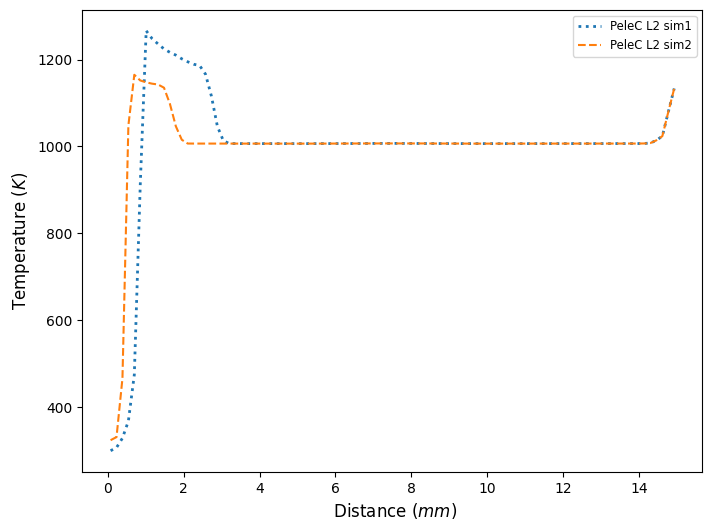

In [5]:
# Profile
# Extract lines

import yt
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Load the datasets

ds = yt.load("plt75000")  # Non-reactive/AMR-L2
#ds = yt.load("plt77719")  # Non-reactive/AMR-L2
ds2 = yt.load("plt90000")  # Non-reactive/AMR-L4

# Define the start and end points for the line along the x-direction
# centro de eje y-z

start_point = [4.2, 0, 0.25] 
end_point = [4.2, 1.5, 0.25]
#start_point = [5.0, 1.484375, 0.25] 
#end_point = [6.0, 1.484375, 0.25]
#start_point = [5.0, 1.5, 0.25] 
#end_point = [6.0, 1.5, 0.25]

# From inputs file:
# geometry.prob_lo     =   0.0  0.0   0.0
# geometry.prob_hi     =   12.5  1.5   0.5

# Create the ray along the y-axis
ray = ds.ray(start_point, end_point)
ray2 = ds2.ray(start_point, end_point)

# Extract the data from the line along the y-axis
x_coordinates = ray["y"]
#data_to_plot_vel = ray["y_velocity"]
data_to_plot_vel = ray["Temp"]
x_coordinates2 = ray2["y"]
#data_to_plot_vel2 = ray2["y_velocity"]
data_to_plot_vel2 = ray2["Temp"]
#data_to_plot_vel = ray["x_velocity"]

#print("x_positions size:", len(x_positions))
#print("values size:", len(values))
areaInj = PI * 
massflow1 = rhoH2 * vel1* areaInj
# Convert to numpy arrays
x_positions = np.array(x_coordinates)
values = np.array(data_to_plot_vel)
x_positions2 = np.array(x_coordinates2)
values2 = np.array(data_to_plot_vel2)

# Sort the data by x positions
sorted_indices = np.argsort(x_positions)
sorted_x_positions = x_positions[sorted_indices]
sorted_values = values[sorted_indices]
sorted_indices2 = np.argsort(x_positions2)
sorted_x_positions2 = x_positions2[sorted_indices2]
sorted_values2 = values2[sorted_indices2]


#REF DATA
#df_vel = pd.read_csv('BLVelRef.csv')

# Create the plots
fig, (ax1) = plt.subplots(1, figsize=(8, 6))

# Temperature plot
#ax1.plot(df_vel.iloc[:, 0] , df_vel.iloc[:, 1], label=r"Ref. L2", color="g", lw=2.5, marker='^', ms=4, alpha=0.6)

ax1.plot(sorted_x_positions / 0.1, sorted_values, label=r"PeleC L2 sim1", linestyle=':', linewidth=2)
ax1.plot(sorted_x_positions2 / 0.1, sorted_values2, label=r"PeleC L2 sim2", linestyle='--')

#ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))  # Two decimals on x-axis
#ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

ax1.set_xlabel(" Distance $(mm)$", fontsize=12)
ax1.set_ylabel(r"Temperature $(K)$", fontsize=12)
ax1.legend(fontsize='small')
#plt.tight_layout()
#plt.savefig('plot1.png', dpi=400)  # Save the figure in high quality
plt.show()

NameError: name 'pi' is not defined